### **t-SNE**

- 비선형 차원 축소 기법으로 고차원 데이터의 국소 구조를 보존하면서 2차원 또는 3차원 시각화를 하기 위해 사용
- 고차원 데이터의 경우에는 거리 기반 유사도(가우시안 분포를 이용한 계산)
- 저차원의 경우에는 확률적으로 비슷하게 재현 (t-분포를 이용한 계산)
    - t-분포를 사용하는 이유: 멀리 떨어진 점 간의 거리 차이를 완화시키기 위한 방법

- 거리 계산 방법
    - 유클리드 거리(euclidean) → 기본적인 거리 방식 (직선의 거리)
    - 맨헤튼 거리(manhattan) → 직각축 기반 거리
    - 체비쇼프 거리(chebyshev) → 최대의 축 차이 기반
    - 코사인 거리(유사도)(cosine) → 벡터 방향 기반 → 자연어 데이터에서 사용
    - 마할라노비스 거리(mahalanobis) → 변수간 상관관계를 반영

- **parameter**
    - `n_components`
        - default : 2
        - 축소할 차원의 개수
    
    - `perplexity`
        - default : 30
        - 이웃의 주 제어 (군집 크기 민감)
        - 보통 5 ~ 50 정도의 값을 사용
        - 값이 작은 경우 작은 구조, 큰 경우 전체의 구조
        - 일반적으로 샘플 개수 / 3
        - 너무 큰 값을 설정하면 전체를 포괄하는 형태가 될 수 있다.
    
    - `early_exaggeration`
        - default : 12
        - 초기 학습에서 군집 간의 거리를 지정 (분리 촉진)
    
    - `learning_rate`
        - default : `auto`
        - 학습의 속도
        - 너무 작게 지정하면 수렴이 느려짐
        - 너무 크게 지정하면 군집이 왜곡
        - 100 ~ 1000 정도 값을 사용

    - `max_iter`
        - default : 1000
        - 전체 학습의 반복 횟수
    
    - `n_iter_without_progress`
        - default : 300
        - 개선이 없을 때 조기 종료의 기준
    
    - `metric`
        - default : `euclidean`
        - 거리 계산 방식


- **속성**
    - `embedding_`
        - 변환된 저차원 데이터를 반환
    - `kl_divergence_`
        - 최종 KL 발산 값을 반환 (작을수록 원래의 구조와 유사)


- **메서드**
    - `fit()`
        - 데이터를 학습
    - `transform()`
        - 데이터를 저차원으로 변환

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
digits = load_digits()

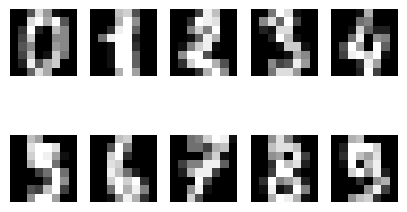

In [4]:
plt.figure(figsize=(5, 3))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='grey')
    plt.axis('off')

plt.show()

In [6]:
pd.DataFrame(digits.data)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [7]:
# 64차원 데이터를 2차원으로 변경
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    n_jobs=-1
)

In [8]:
X = StandardScaler().fit_transform(digits['data'])
y = digits['target']

In [9]:
X_tsne = tsne.fit_transform(X)

In [10]:
print(X.shape)
print(X_tsne.shape)

(1797, 64)
(1797, 2)


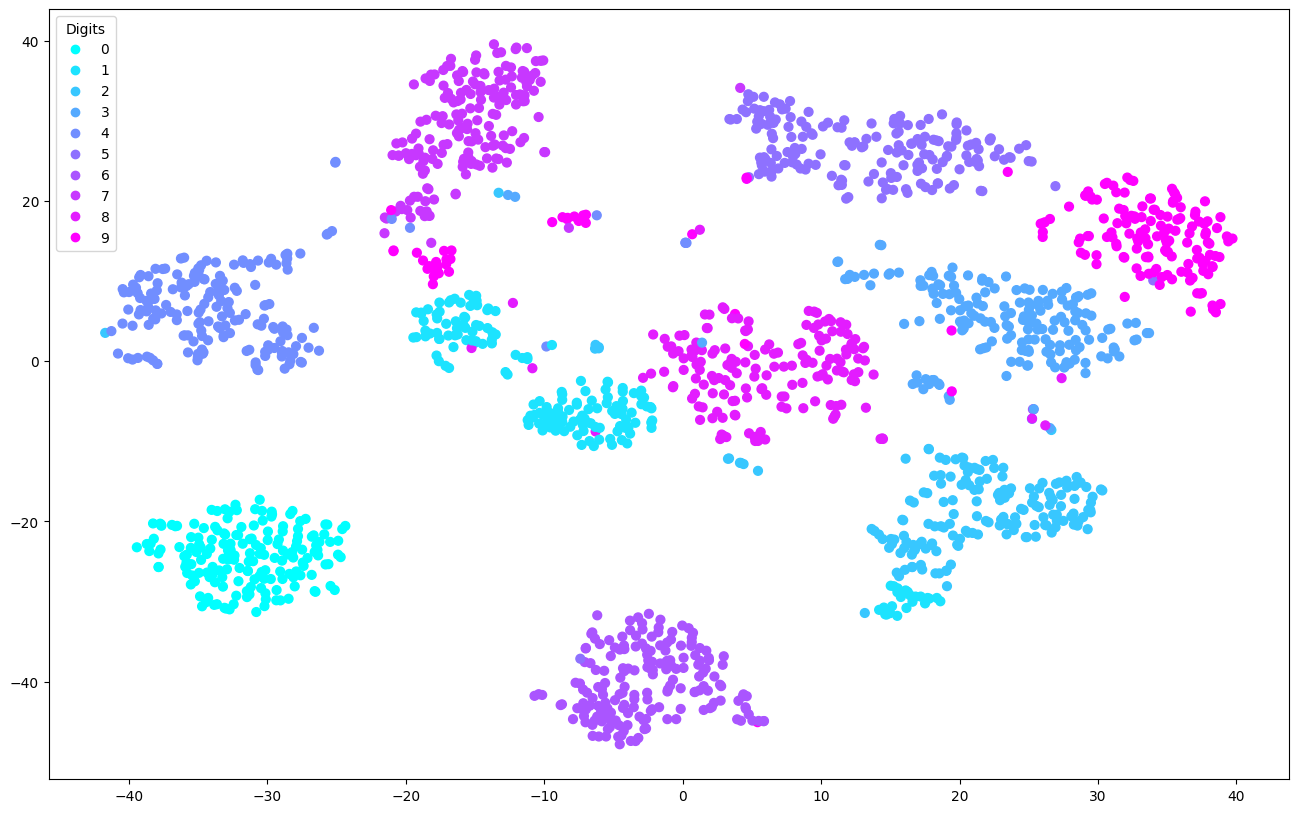

In [12]:
plt.figure(figsize=(16, 10))

sc = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], c = y, cmap = 'cool', s = 40
)

plt.legend(*sc.legend_elements(), title='Digits')
plt.show()

5월 19일

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [3]:
# 10차원 군집 데이터 3개 생성
X, y = make_blobs(n_samples=600, centers=3, n_features=10, cluster_std=1.5, random_state=42)

# Scaling
X_std = StandardScaler().fit_transform(X)

In [4]:
tsne = TSNE(n_components=2, perplexity=40, learning_rate=250, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_std)

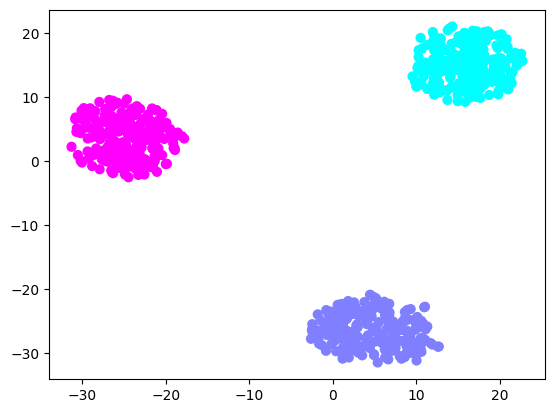

In [5]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = y, cmap='cool', s = 40)
plt.show()

In [7]:
# body data를 tsne로 차원 축소
body = pd.read_csv('../data/bodyPerformance.csv')
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [8]:
from sklearn.preprocessing import LabelEncoder

In [10]:
obj_col = body.select_dtypes('object').columns
le = LabelEncoder()

for col in obj_col:
    body[col] = le.fit_transform(body[col])

C:\Users\hkssn\AppData\Local\Temp\ipykernel_15212\257051717.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_col = body.select_dtypes('object').columns


In [11]:
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [12]:
# 데이터 분할 (독립/종속)
X = body.drop(['gender', 'class'], axis = 1)
y1 = body['class']
y2 = body['gender']

In [13]:
X_std = StandardScaler().fit_transform(X)

In [14]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    random_state=42
)

In [15]:
X_tsne = tsne.fit_transform(X_std)

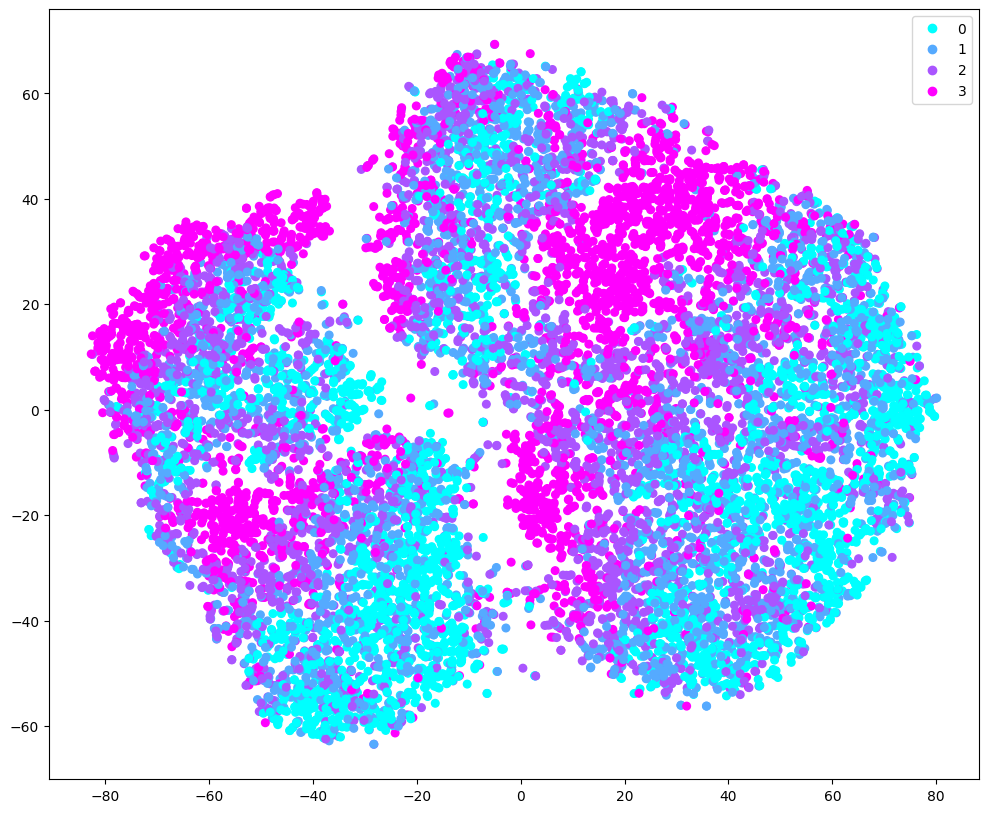

In [16]:
plt.figure(figsize = (12, 10))

sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = y1, cmap='cool', s = 30)
plt.legend(*sc.legend_elements())

plt.show()

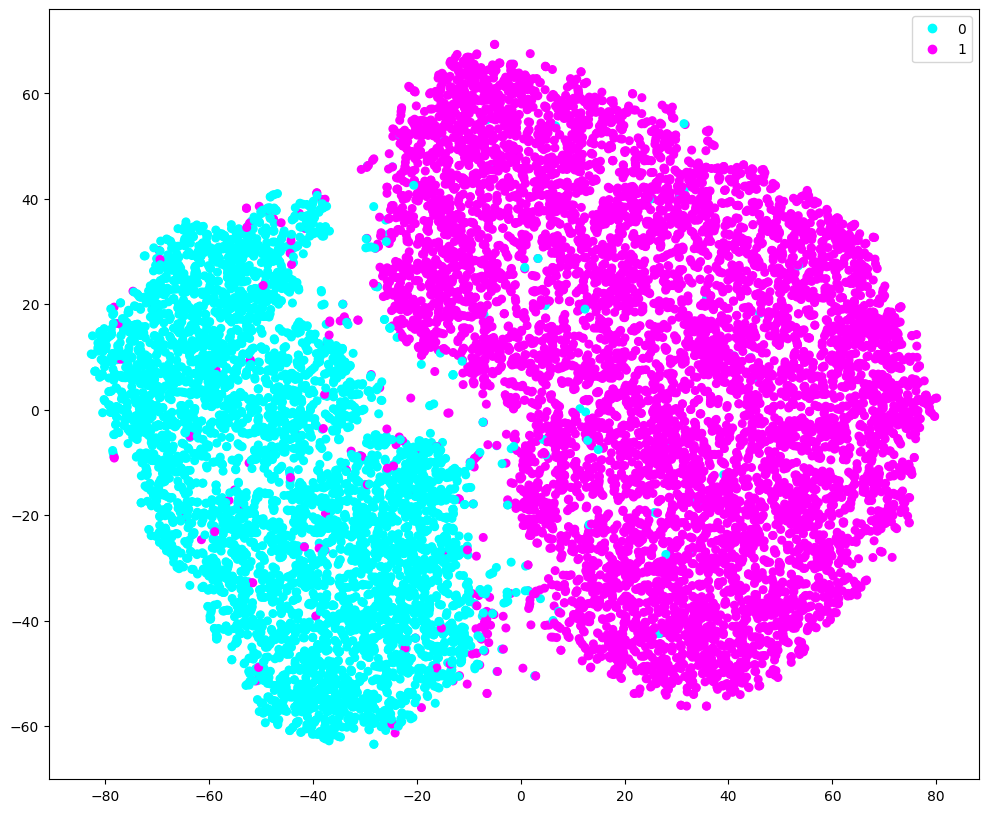

In [17]:
plt.figure(figsize = (12, 10))

sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = y2, cmap='cool', s = 30)
plt.legend(*sc.legend_elements())

plt.show()

In [ ]:
# 결과 확인 → kl_divergence_ : 고차원과 저차원 확률 분포의 차이 (작을수록 좋음)
tsne.kl_divergence_

2.4155325889587402